In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg


In [2]:
game_set = pd.read_csv('C:/Users/user/my_pet_project')
game_set.head(5)

,appid,name,collected_genre,price,positive,negative,avg_playtime,max_player_online,developer,publisher,release_date,metacritic_score
0,730,Counter-Strike: Global Offensive,Action,0,7642084,1173003,33597,1013936,Valve,Valve,2012-08-21,83
1,1172470,Apex Legends,Action,0,668053,326926,10093,124262,Respawn,Electronic Arts,2020-11-04,88.0
2,578080,PUBG: BATTLEGROUNDS,Action,0,1520457,1037487,24569,314682,PUBG Corporation,"KRAFTON, Inc.",2017-12-21,86
3,1623730,Palworld,Action,2999,358266,22443,3869,18028,Pocketpair,Pocketpair,2024-01-18,71
4,440,Team Fortress 2,Action,0,1044264,117208,23070,43819,Valve,Valve,2007-10-10,92.0


<h3>Гипотеза 1:

Существует ли зависимость между ценой за игру и продажами?
Есть ли "Золотая середина" (игры за 30$ продаются лучше, чем за 20 или 40)?</h3>

Добавляю колонки для проверки гипотез

In [3]:
#перевожу цену в доллары
game_set['price_usd'] = game_set['price'] / 100 

game_set['total_reviews'] = game_set['positive'] + game_set['negative']
game_set['negative_reviews_ratio'] = round(game_set['negative']/game_set['total_reviews']*100,2)
game_set['positive_reviews_ratio'] = round(game_set['positive']/game_set['total_reviews']*100,2)

# продажи посчитаны по кол-ву отзывов
game_set['sales'] = game_set['total_reviews']*game_set['price']
game_set['log_sales'] = np.log1p(game_set['sales'])

# Отдельная колонка в млн (для удобства визуализаций и подсчётов)
game_set['sales_mln'] = round(game_set['sales']/1000000,2)

# разделяю игры по ценовому сегменту
game_set['price_segment'] = game_set['price_usd'].apply(
    lambda x: '0$' if x == 0
    else '10$' if x <= 10
    else '20$' if x <= 20
    else '30$' if x <= 30
    else '40$' if x <= 40
    else '50$' if x <= 50
    else '60$' if x <= 60
    else '70$'
)

# Разрыв оценок между пользователями и критиками
game_set['metacritic_score'] = pd.to_numeric(game_set['metacritic_score'], errors='coerce')
game_set['metacritic_score'] = game_set['metacritic_score'].fillna(0).astype(int)
game_set['gap_score'] = game_set['positive_reviews_ratio'] - game_set['metacritic_score']


Делаю 2 отдельных датасета для анализа и визуализации

In [4]:

top_price_and_genre = game_set.groupby(['price_segment','collected_genre'], as_index = False)\
                              .agg({'max_player_online':'median', 'negative_reviews_ratio':'mean', 'sales':'median'})
top_price_and_genre['negative_reviews_ratio'] = top_price_and_genre['negative_reviews_ratio'].round(2)
top_price_and_genre.rename(columns={'sales': 'sales','avg_player_online':'max_player_online'}, inplace=True)
top_price_and_genre['sales'] = round(top_price_and_genre['sales']/1000000,2)
top_price_and_genre['log_sales'] = np.log1p(top_price_and_genre['sales'])


top_price_segment = top_price_and_genre.groupby('price_segment', as_index = False)\
                                       .agg({'max_player_online':'median', 'negative_reviews_ratio':'mean', 'sales':'median'})
top_price_segment['negative_reviews_ratio'] = top_price_segment['negative_reviews_ratio'].round(2)

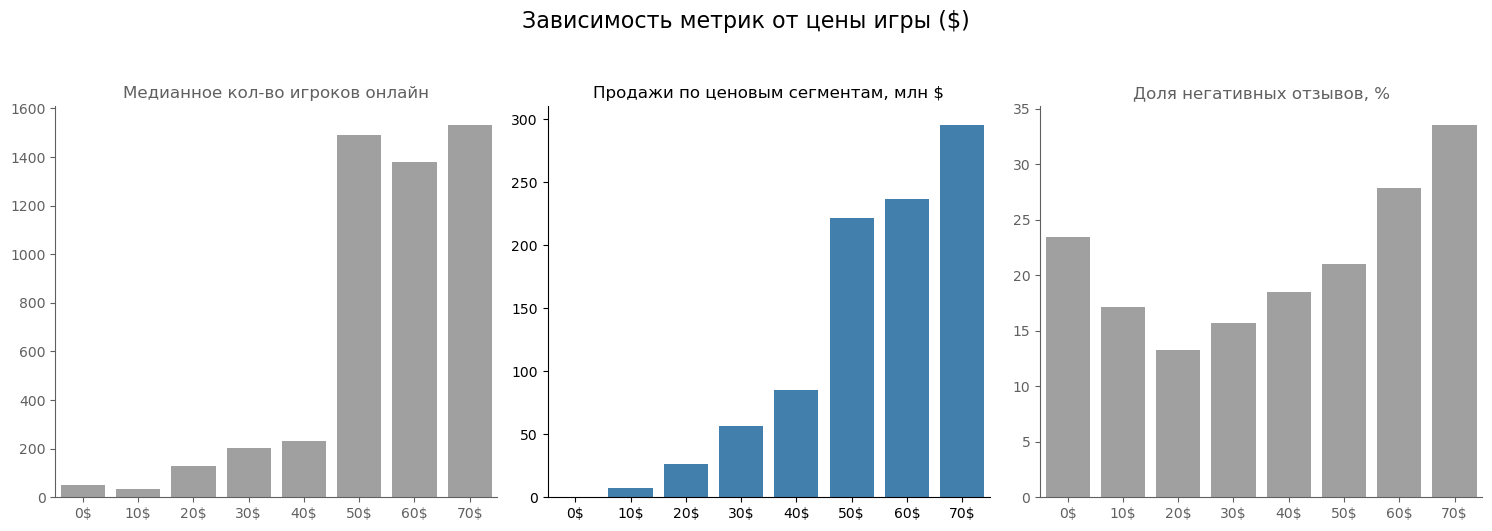

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.despine(top=True, right=True)

sns.barplot(data=top_price_segment, x='price_segment', y='max_player_online', ax=axes[0], color='#A0A0A0')
sns.barplot(data=top_price_segment, x='price_segment', y='sales', ax=axes[1],color='#3182BD')
sns.barplot(data=top_price_segment, x='price_segment', y='negative_reviews_ratio', ax=axes[2], color='#A0A0A0')

axes[0].set_title('Медианное кол-во игроков онлайн', color='#606060')
axes[1].set_title('Продажи по ценовым сегментам, млн $')
axes[2].set_title('Доля негативных отзывов, %', color='#606060')
fig.suptitle('Зависимость метрик от цены игры ($)', fontsize=16, y=1.05)

axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[2].set_xlabel('')

axes[0].spines['bottom'].set_color('#606060')
axes[0].spines['left'].set_color('#606060')
axes[0].tick_params(axis='both', colors='#606060')

axes[2].spines['bottom'].set_color('#606060')
axes[2].spines['left'].set_color('#606060')
axes[2].tick_params(axis='both', colors='#606060')

plt.tight_layout(pad=1.0)
plt.show()

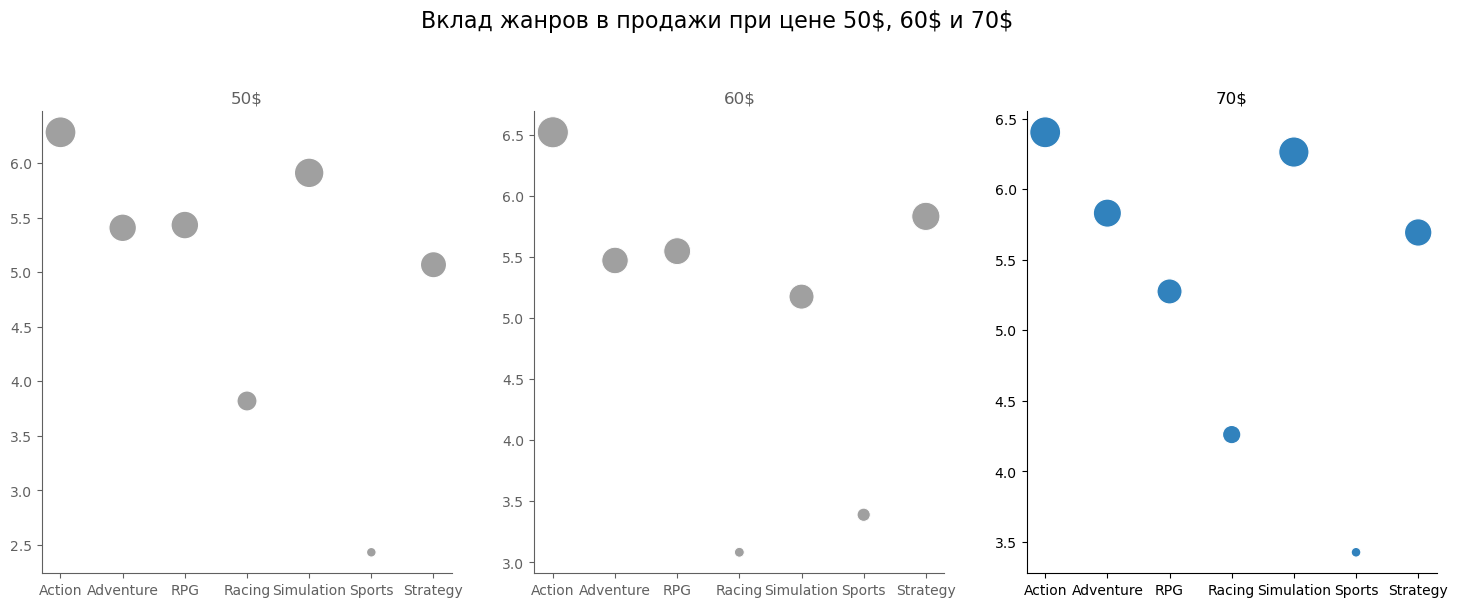

,price_segment,genre_type,sales
0,50$,Action,533.640
1,50$,Other_genre,189.770
2,60$,Action,677.100
3,60$,Other_genre,206.115
4,70$,Action,602.330
5,70$,Other_genre,245.050


In [6]:
top_segment_sales = ['50$','60$','70$']
top_3_segment = top_price_and_genre.query('price_segment in @top_segment_sales').copy()
top_3_segment['genre_type'] = top_3_segment['collected_genre'].apply(lambda x: 'Action' if x == 'Action' else 'Other_genre')
top_3_segment = top_3_segment.groupby(['price_segment','genre_type'], as_index = False).agg({'sales':'median'})


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.despine(top=True, right=True)

sns.scatterplot(data=top_price_and_genre.query('price_segment == "50$"'), x='collected_genre', y='log_sales', size='log_sales',sizes=(50, 500),  legend=False, ax=axes[0], color='#A0A0A0')
sns.scatterplot(data=top_price_and_genre.query('price_segment == "60$"'), x='collected_genre', y='log_sales', size='log_sales',sizes=(50, 500),  legend=False, ax=axes[1],color='#A0A0A0')
sns.scatterplot(data=top_price_and_genre.query('price_segment == "70$"'), x='collected_genre', y='log_sales', size='log_sales',sizes=(50, 500),  legend=False, ax=axes[2], color='#3182BD')

axes[0].set_title('50$', color='#606060')
axes[1].set_title('60$', color='#606060')
axes[2].set_title('70$')
fig.suptitle('Вклад жанров в продажи при цене 50$, 60$ и 70$', fontsize=16, y=1.05)

axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[2].set_xlabel('')

axes[0].spines['bottom'].set_color('#606060')
axes[0].spines['left'].set_color('#606060')
axes[0].tick_params(axis='both', colors='#606060')

axes[1].spines['bottom'].set_color('#606060')
axes[1].spines['left'].set_color('#606060')
axes[1].tick_params(axis='both', colors='#606060')

plt.show()

display(top_3_segment)

Проведение стат. тестов для подтверждения гипотезы

In [7]:
# Проверка нормальности (при логарифмированных данных распределение также ненормальное)
for segment in game_set['price_segment'].unique():
    statistic, p_value = stats.normaltest(game_set[game_set['price_segment'] == segment]['sales'])
    print(f"{segment}, p_value:{p_value}")
print ('Распределение нормальное только для 1 группы - 70$')

0$, p_value:nan
30$, p_value:4.1033442827984764e-44
40$, p_value:5.309032212608221e-40
60$, p_value:9.39072363534719e-12
10$, p_value:3.9503135266878062e-227
20$, p_value:8.105803199781816e-184
50$, p_value:7.777629175478617e-07
70$, p_value:0.22051648191153642
Распределение нормальное только для 1 группы - 70$


C:\Users\user\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [8]:
# Для сравнения 8 групп применяю Краскела - Уоллиса при ненормалньом распределинии

stattest = pg.kruskal(data=game_set, dv='sales', between='price_segment')
p_value = stattest['p_unc'].values[0]
print (f'p_value:{p_value:.4f}')


p_value:0.0000


In [9]:
# Группы стат. значимо различаются. Провожу попарный анализ для выявления конкретных групп

posthoc = pg.pairwise_tests(
    data=game_set,
    dv='sales',           
    between='price_segment',  
    parametric=False,         
    padjust='holm'      
)
print(posthoc.head(10))

        Contrast    A    B  Paired  Parametric    U_val alternative  \
0  price_segment   0$  10$   False       False    590.0   two-sided   
1  price_segment   0$  20$   False       False      0.0   two-sided   
2  price_segment   0$  30$   False       False    295.0   two-sided   
3  price_segment   0$  40$   False       False      0.0   two-sided   
4  price_segment   0$  50$   False       False      0.0   two-sided   
5  price_segment   0$  60$   False       False      0.0   two-sided   
6  price_segment   0$  70$   False       False      0.0   two-sided   
7  price_segment  10$  20$   False       False  89834.0   two-sided   
8  price_segment  10$  30$   False       False  25474.0   two-sided   
9  price_segment  10$  40$   False       False   8544.0   two-sided   

           p_unc         p_corr p_adjust    hedges  
0  5.436952e-230  1.522347e-228     holm -0.345425  
1  2.253911e-220  6.085560e-219     holm -0.559393  
2  3.460638e-180  8.997660e-179     holm -1.167381  
3  2.7

In [10]:
#Корреляция между ценой и продажами
top_price_segment['price_segment_value'] = top_price_segment['price_segment'].str.replace('$', '').astype(int)
corr = top_price_segment['price_segment_value'].corr(top_price_segment['sales']).round(2)

print(f"Корреляция Пирсона: {corr:.3f}")

Корреляция Пирсона: 0.950


Вывод 1 гипотезы:

В результате анализа выявлена зависимость между ценой игры и 
объемами продаж. В диапазоне цен от 0 до 40$ каждое повышение цены на 10 
приводит к статистически значимому росту продаж (p < 0.05). 

В диапазоне от 40 до 70$ различия в продажах статистически незначимы (p > 0.05). Корреляция Пирсона между ценой и продажами 
составляет 0.95, что указывает на очень сильную связь.

<h3>Гипотеза 2:

В каких жанрах разница между Metacritic и отзывами игроков максимален? Есть ли жанры, где критики систематически занижают или завышают оценки?
    </h3>

Подготовка тадицы к анализу 2 гипотезы

In [11]:
game_set_clean = game_set.query('metacritic_score != 0').copy()
genre_gap_all = game_set_clean.groupby('collected_genre')\
                              .agg(median_gap_all=('gap_score', 'median'), mean_gap_all=('gap_score', 'mean'),\
                                   std_all=('gap_score', 'std'), count = ('gap_score', 'count')).round(2).reset_index()

# Границы доверительного интервала
genre_gap_all['di_lower'] = round(genre_gap_all['mean_gap_all'] - stats.t.ppf(0.975, df=genre_gap_all['count'] - 1)*\
                                 (genre_gap_all['std_all'] / np.sqrt(genre_gap_all['count'])),2)
genre_gap_all['di_upper'] = round(genre_gap_all['mean_gap_all'] + stats.t.ppf(0.975, df=genre_gap_all['count'] - 1) *\
                                 (genre_gap_all['std_all'] / np.sqrt(genre_gap_all['count'])),2)

genre_gap_negative= game_set_clean.query('gap_score < 0').groupby('collected_genre').agg(mean_gap_negative = ('gap_score','mean')).round(2).reset_index()
genre_gap_positive = game_set_clean.query('gap_score > 0 and metacritic_score != 0').groupby('collected_genre')\
                                   .agg(mean_gap_positive = ('gap_score','mean')).round(2).reset_index()

genre_gap = genre_gap_all.merge(genre_gap_negative, on='collected_genre').merge(genre_gap_positive, on='collected_genre')

genre_gap

,collected_genre,median_gap_all,mean_gap_all,std_all,count,di_lower,di_upper,mean_gap_negative,mean_gap_positive
0,Action,7.31,6.56,9.96,430,5.62,7.50,-8.48,10.21
1,Adventure,11.08,10.31,7.52,85,8.69,11.93,-2.95,11.88
2,Indie,10.52,11.96,9.28,28,8.36,15.56,-8.34,12.71
3,RPG,6.84,5.44,9.88,183,4.00,6.88,-8.24,9.26
4,Racing,8.06,7.64,11.51,46,4.22,11.06,-7.89,11.96
5,Simulation,9.74,7.33,15.27,66,3.58,11.08,-14.15,13.12
6,Sports,5.28,3.98,11.29,66,1.20,6.76,-9.92,9.19
7,Strategy,8.12,6.47,10.72,153,4.76,8.18,-9.94,10.15


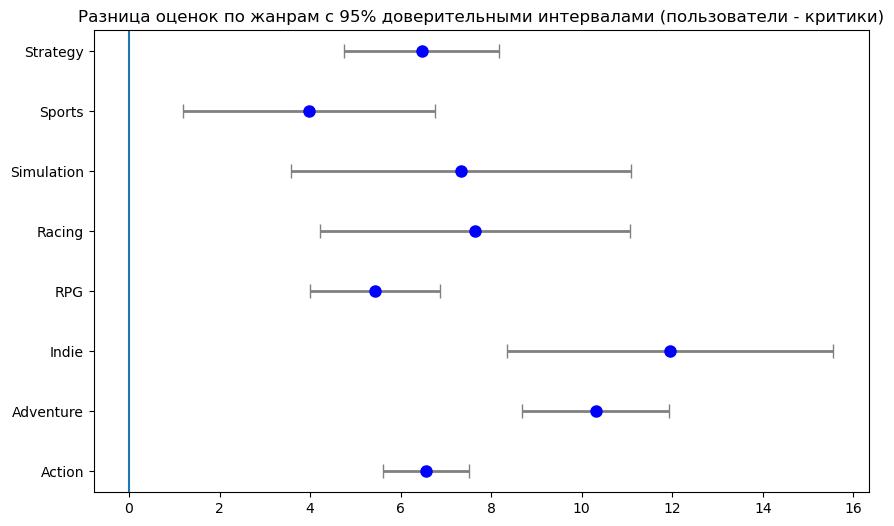

Количество игр по жанрам:


collected_genre
Indie          73
Adventure     157
Simulation    221
Racing        307
Strategy      346
RPG           379
Sports        428
Action        496
Name: count, dtype: int64

In [12]:
genres = genre_gap.collected_genre.tolist()
means = genre_gap.mean_gap_all.tolist()
lower = genre_gap.di_lower.tolist()
upper = genre_gap.di_upper.tolist()

error_low = [means[i] - lower[i] for i in range(len(means))]
error_high = [upper[i] - means[i] for i in range(len(means))]
errors = [error_low, error_high]

plt.figure(figsize=(10, 6))
plt.errorbar(means, genres, xerr=errors, fmt='o', capsize=5, 
             color='blue', ecolor='gray', elinewidth=2, markersize=8)

plt.axvline(x=0)
plt.title('Разница оценок по жанрам с 95% доверительными интервалами (пользователи - критики)')
plt.show()

print("Количество игр по жанрам:")
display(game_set['collected_genre'].value_counts().sort_index().sort_values())

Вывод 2 гипотезы:

Анализ разницы между оценками пользователей и критиков (шкала 0-100 баллов) показал, 
что во всех жанрах пользователи оценивают игры выше. 

Наибольшее расхождение наблюдается в жанре Indie (пользователи в среднем выше на 12 
баллов), наименьшее - в Sports (4 балла). Остальные жанры занимают 
промежуточное положение (от 5 до 10 баллов).

Размер выборки варьируется от 73 (Indie) до 496 (Action) игр. Жанры с 
наименьшим количеством наблюдений (Indie, Adventure, Simulation) требуют 
осторожной интерпретации, так как доверительные интервалы для них шире.

<h3>Гипотеза 3:

Существует ли связь между датой (месяцем) релиза и продажами? Если да, то какой самый прибыльный месяц или сезон?
</h3>

Делаю таблицу с медианными продажами за каждый месяц, так как есть сильные выбросы (хиты)

In [13]:
game_set['month'] = pd.to_datetime(game_set['release_date']).dt.month

game_set['sales_mln'] = round(game_set['sales']/1000000,2)

month_sales = game_set.groupby('month', as_index = False).agg({'sales_mln':'median'}).sort_values('sales_mln', ascending = False)

month_sales

print(month_sales)

corr = game_set['month'].corr(game_set['sales_mln'], method='spearman')
print(f"\nКорреляция Спирмена между месяцем и продажами: {corr:.3f}")


    month  sales_mln
8     9.0     18.630
10   11.0     16.110
0     1.0     13.010
9    10.0     11.565
5     6.0      7.700
2     3.0      7.360
7     8.0      7.065
4     5.0      5.420
1     2.0      5.060
3     4.0      4.695
11   12.0      3.800
6     7.0      2.040

Корреляция Спирмена между месяцем и продажами: 0.015


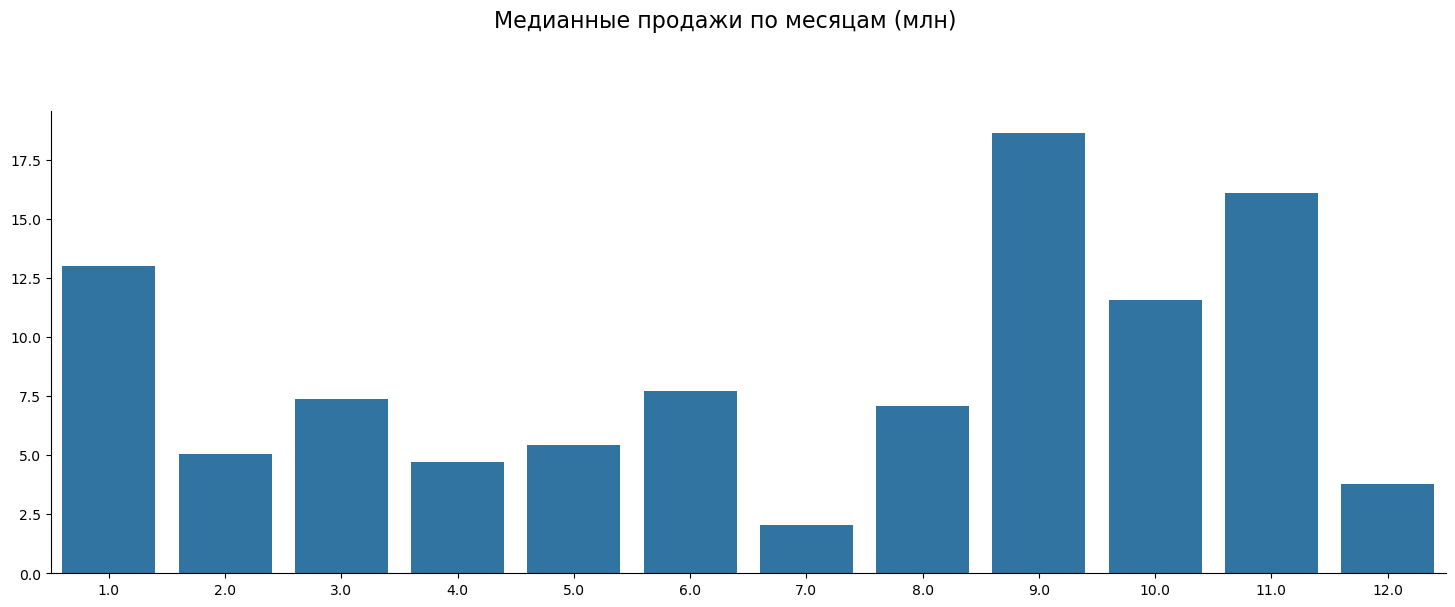

In [14]:
fig, axes = plt.subplots( figsize=(18, 6))
sns.barplot(x = 'month', y = 'sales_mln', data = month_sales)
sns.despine(top=True, right=True)
fig.suptitle('Медианные продажи по месяцам (млн)', fontsize=16, y=1.05)
plt.ylabel('')
plt.xlabel('')
plt.show()

In [15]:
stattest = pg.kruskal(data=game_set, dv='sales_mln', between='month')
p_value = stattest['p_unc'].values[0]
print (f'p_value:{p_value:.4f}')

p_value:0.0054


Вывод 3 гипотезы:

Месяц релиза значимо влияет на продажи игр (p < 0.05),
однако взаимосвязь между месяцем и продажами отсутствует
(Корреляция Спирмена = 0.015).

Эти результаты не противоречат друг другу: значимые различия между месяцами
существуют, но они нелинейны.

Наибольшие продажи показывают игры, выпущенные в сентябре (18.6 млн) и ноябре (16.1 млн). Наименьшие - в июне (2.0 млн) и декабре (3.8 млн).

Наиболее прибыльный сезон для релиза - осень.

Заключение:

На основе анализа данных о видеоиграх были проверены три гипотезы:

1. ЗАВИСИМОСТЬ ОТ ЦЕНЫ: Выявлена сильная взаимосвязь между ценой игры 
   и продажами (r = 0.95). До 40$ повышение цены значимо увеличивает продажи, 
   после 40 дальнейший рост цены не дает прироста продаж.

2. РАЗНИЦА В ОЦЕНКАХ: Во всех жанрах пользователи оценивают игры выше критиков. 
   Максимальный разрыв — в Indie (12 баллов), минимальный — в Sports (4 балла). 
   Жанры с малым количеством наблюдений (Indie, Adventure) требуют осторожной 
   интерпретации.

3. СЕЗОННОСТЬ РЕЛИЗОВ: Месяц выхода игры значимо влияет на продажи (p < 0.05). 
   Лучшие месяцы для релиза — сентябрь и ноябрь, худший — июнь. Осень является 
   наиболее прибыльным сезоном для выпуска новых игр.

ИТОГОВЫЕ РЕКОМЕНДАЦИИ:
- Оптимальная цена игры — 40$ (дальнейшее повышение не увеличивает продажи)
- Инди-играм стоит уделять внимание — пользователи высоко их оценивают
- Релизы планировать на осень, избегая июня